# IMPLEMENTACIÓN DE UN MODELO DE APRENDIZAJE AUTOMÁTICO CUÁNTICO UTILIZANDO QISKIT MACHINE LEARNING
## Proyecto Segunda Parte: Experimentación en Hardware Cuántico Real de IBM

**Universidad Nacional de San Antonio Abad del Cusco**  
**Departamento Académico de Informática**  
**Curso:** Computación Cuántica  

**Autores:** Edmil Jampier Saire Bustamante · Medaly Lozano Llacctahuaman · José Francisco Puma Potosino  

---

### Pregunta de Investigación
> *¿Cuál es el impacto real del ruido de hardware en el rendimiento de clasificadores cuánticos (VQC, QSVC) y qué técnicas de mitigación de errores recuperan mayor fidelidad respecto al simulador ideal?*

### Experimentos
 #  Experimento  Entorno  QPU 
----------------------------
 1  Baseline Corregido (VQC + QSVC + Clásicos)  Simulador Ideal  0 min 
 2  Estado de Bell — Prueba de Concepto  Hardware Real IBM  ~3s 
 3  QSVC — Kernel Cuántico en Hardware Real  Hardware Real IBM  ~2 min 
 4  Mitigación de Errores (TREX)  Hardware Real IBM  ~2.5 min 
 5  Clasificación MNIST Binaria en Hardware  Hardware Real IBM  ~2.5 min 
   **Total estimado**  **~7 min** 

---
##  Sección 0: Instalación y Configuración

> **IMPORTANTE:** Esta sección NO usa tiempo de QPU. Se puede ejecutar libremente.

In [33]:
# ============================================================
# CELDA 0A: INSTALACIÓN DE DEPENDENCIAS
# ============================================================
!pip install -q qiskit qiskit-ibm-runtime qiskit-machine-learning qiskit-aer scikit-learn matplotlib numpy pandas


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
# ============================================================
# CELDA 0B: IMPORTS GENERALES
# ============================================================
import json
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.primitives import StatevectorSampler

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

from qiskit_machine_learning.algorithms import VQC
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.optimizers import COBYLA

warnings.filterwarnings('ignore')
np.random.seed(42)

# Estilo dark mode para gráficos
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#c9d1d9',
    'text.color': '#c9d1d9', 'xtick.color': '#8b949e',
    'ytick.color': '#8b949e', 'grid.color': '#21262d',
    'font.size': 11, 'figure.dpi': 120
})

import qiskit
print(f' Imports OK — Qiskit {qiskit.__version__}')

 Imports OK — Qiskit 2.4.1


In [35]:
# ============================================================
# CELDA 0C: CONEXIÓN A IBM QUANTUM
# ============================================================
# ▶ Si se agota la cuota, cambia el apikey.json y EJECUTA SOLO
#   ESTA CELDA para reconectar sin perder datos.
# ============================================================

try:
    with open('../apikey.json', 'r') as f:
        api_key = json.load(f)['apikey']
    print('Credenciales API cargadas exitosamente.')
except FileNotFoundError:
    api_key = 'TU_API_KEY_AQUI'  # ← Pega tu key aquí si no usas archivo
    print(' API Key definida manualmente')

service = QiskitRuntimeService(channel='ibm_quantum_platform', token=api_key)
backends = service.backends()
print(f'\n Conectado a IBM Quantum — {len(backends)} backends:')
for b in backends:
    print(f'   • {b.name} — {b.num_qubits} qubits')

backend = service.least_busy(operational=True, simulator=False)
print(f'\n Backend: {backend.name} ({backend.num_qubits} qubits)')

qiskit_runtime_service._discover_account:WARNING:2026-06-12 19:08:28,671: Loading account with the given token. A saved account will not be used.


Credenciales API cargadas exitosamente.


qiskit_runtime_service.__init__:WARNING:2026-06-12 19:08:34,979: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-12 19:08:34,979: Loading instance: open-instance, plan: open



 Conectado a IBM Quantum — 3 backends:
   • ibm_fez — 156 qubits
   • ibm_marrakesh — 156 qubits
   • ibm_kingston — 156 qubits


qiskit_runtime_service.backends:WARNING:2026-06-12 19:08:39,056: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-12 19:08:41,311: Using instance: open-instance, plan: open



 Backend: ibm_marrakesh (156 qubits)


In [36]:
# ============================================================
# CELDA 0D: CONFIGURACIÓN GLOBAL + SISTEMA DE CHECKPOINTS
# ============================================================

# --- Parámetros optimizados para caber en 10 min de QPU ---
N_TRAIN_HW = 10     # Muestras de entrenamiento (Severamente restringido por cuota QPU)
N_TEST_HW  = 5      # Muestras de validación (Severamente restringido por cuota QPU)
SHOTS      = 2048   # shots por circuito
SEED       = 42

# Carpeta para guardar checkpoints
CHECKPOINT_DIR = 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Diccionario global de resultados
resultados_globales = {}

def guardar_checkpoint(nombre, datos):
    """Guarda un checkpoint a disco (numpy arrays y escalares)."""
    path = os.path.join(CHECKPOINT_DIR, f'{nombre}.npz')
    np.savez(path, **datos)
    print(f'    Checkpoint guardado: {path}')

def cargar_checkpoint(nombre):
    """Carga un checkpoint desde disco."""
    path = os.path.join(CHECKPOINT_DIR, f'{nombre}.npz')
    if os.path.exists(path):
        data = dict(np.load(path, allow_pickle=True))
        print(f'   📂 Checkpoint cargado: {path}')
        return data
    return None

def existe_checkpoint(nombre):
    return os.path.exists(os.path.join(CHECKPOINT_DIR, f'{nombre}.npz'))

print('  Configuración optimizada:')
print(f'   Subset HW:  {N_TRAIN_HW} train / {N_TEST_HW} test')
print(f'   Shots:       {SHOTS}')
print(f'   Circuitos por experimento: {N_TRAIN_HW**2 + N_TEST_HW*N_TRAIN_HW} = {N_TRAIN_HW}²+{N_TEST_HW}×{N_TRAIN_HW}')
print(f'   Backend:     {backend.name}')
print(f'   Checkpoints: {CHECKPOINT_DIR}/')

  Configuración optimizada:
   Subset HW:  10 train / 5 test
   Shots:       2048
   Circuitos por experimento: 150 = 10²+5×10
   Backend:     ibm_marrakesh
   Checkpoints: checkpoints/


---
##  Sección 1: Carga y Preprocesamiento de Datos
> **QPU:** 0 min (todo local)

In [37]:
# ============================================================
# CELDA 1A: DATASET IRIS
# ============================================================
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

scaler_iris = MinMaxScaler(feature_range=(0, np.pi))
X_iris_scaled = scaler_iris.fit_transform(X_iris)

ohe = OneHotEncoder(sparse_output=False)
y_iris_oh = ohe.fit_transform(y_iris.reshape(-1, 1))

X_tr, X_te, y_tr_oh, y_te_oh = train_test_split(
    X_iris_scaled, y_iris_oh, test_size=0.3,
    stratify=y_iris, random_state=SEED
)
y_tr = y_tr_oh.argmax(axis=1)
y_te = y_te_oh.argmax(axis=1)

# Subconjuntos para hardware
X_tr_hw = X_tr[:N_TRAIN_HW]
X_te_hw = X_te[:N_TEST_HW]
y_tr_hw = y_tr[:N_TRAIN_HW]
y_te_hw = y_te[:N_TEST_HW]

print(f' Iris: {X_tr.shape[0]} train / {X_te.shape[0]} test (total)')
print(f'   HW subset: {N_TRAIN_HW} train / {N_TEST_HW} test')

 Iris: 105 train / 45 test (total)
   HW subset: 10 train / 5 test


In [38]:
# ============================================================
# CELDA 1B: DATASET MNIST REDUCIDO (0 vs 1)
# ============================================================
digits = load_digits()
mask = np.isin(digits.target, [0, 1])
X_mnist = digits.data[mask]
y_mnist = digits.target[mask]

pca_mnist = PCA(n_components=4, random_state=SEED)
X_mnist_pca = pca_mnist.fit_transform(X_mnist)
X_mnist_scaled = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(X_mnist_pca)

y_mnist_oh = OneHotEncoder(sparse_output=False).fit_transform(y_mnist.reshape(-1, 1))

X_m_tr, X_m_te, y_m_tr_oh, y_m_te_oh = train_test_split(
    X_mnist_scaled, y_mnist_oh, test_size=0.3,
    stratify=y_mnist, random_state=SEED
)
y_m_tr = y_m_tr_oh.argmax(axis=1)
y_m_te = y_m_te_oh.argmax(axis=1)

X_m_tr_hw = X_m_tr[:N_TRAIN_HW]
X_m_te_hw = X_m_te[:N_TEST_HW]
y_m_tr_hw = y_m_tr[:N_TRAIN_HW]
y_m_te_hw = y_m_te[:N_TEST_HW]

print(f' MNIST (0 vs 1): {X_m_tr.shape[0]} train / {X_m_te.shape[0]} test')
print(f'   HW subset: {N_TRAIN_HW} train / {N_TEST_HW} test')
print(f'   PCA varianza: {pca_mnist.explained_variance_ratio_.sum():.2%}')

 MNIST (0 vs 1): 252 train / 108 test
   HW subset: 10 train / 5 test
   PCA varianza: 73.44%


---
## 🧪 Sección 2: Experimento 1 — Baseline en Simulador
> **QPU:** 0 min (todo local)  
> Corrige el VQC de la Primera Parte (37.78% → esperamos 80%+) y establece baselines clásicos.

In [39]:
# ============================================================
# CELDA 2A: BASELINES CLÁSICOS
# ============================================================
print(' Modelos clásicos...')

# SVM-RBF
t0 = time.time()
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED)
svm.fit(X_tr, y_tr)
t_svm = time.time() - t0
y_pred_svm = svm.predict(X_te)
acc_svm = accuracy_score(y_te, y_pred_svm)
f1_svm = f1_score(y_te, y_pred_svm, average='macro')
print(f'   SVM-RBF:  Acc={acc_svm:.4f}  F1={f1_svm:.4f}')

# MLP
t0 = time.time()
mlp = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=2000, random_state=SEED)
mlp.fit(X_tr, y_tr)
t_mlp = time.time() - t0
y_pred_mlp = mlp.predict(X_te)
acc_mlp = accuracy_score(y_te, y_pred_mlp)
f1_mlp = f1_score(y_te, y_pred_mlp, average='macro')
print(f'   MLP:      Acc={acc_mlp:.4f}  F1={f1_mlp:.4f}')

# KNN
t0 = time.time()
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_tr, y_tr)
t_knn = time.time() - t0
y_pred_knn = knn.predict(X_te)
acc_knn = accuracy_score(y_te, y_pred_knn)
f1_knn = f1_score(y_te, y_pred_knn, average='macro')
print(f'   KNN:      Acc={acc_knn:.4f}  F1={f1_knn:.4f}')

resultados_globales['SVM-RBF'] = {'accuracy': acc_svm, 'f1': f1_svm, 'tiempo': t_svm, 'entorno': 'Clásico'}
resultados_globales['MLP'] = {'accuracy': acc_mlp, 'f1': f1_mlp, 'tiempo': t_mlp, 'entorno': 'Clásico'}
resultados_globales['KNN'] = {'accuracy': acc_knn, 'f1': f1_knn, 'tiempo': t_knn, 'entorno': 'Clásico'}

 Modelos clásicos...
   SVM-RBF:  Acc=0.9333  F1=0.9333
   MLP:      Acc=0.9333  F1=0.9333
   KNN:      Acc=0.9333  F1=0.9327


In [40]:
# ============================================================
# CELDA 2B: VQC CORREGIDO (3 semillas × 300 iteraciones)
# ============================================================
print(' VQC corregido (3 semillas × 300 iteraciones)...')
print('   Esto tarda ~2-3 minutos (local, sin QPU)...\n')

vqc_accuracies = []
vqc_losses_all = []
best_vqc_acc = 0
best_vqc_model = None

seeds = [42, 123, 789]

for i, seed in enumerate(seeds):
    np.random.seed(seed)
    fm = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
    ans = RealAmplitudes(num_qubits=4, reps=3, entanglement='linear')

    hist = {'loss': []}
    def callback(weights, loss, *args):
        hist['loss'].append(loss)

    t0 = time.time()
    vqc = VQC(
        feature_map=fm, ansatz=ans, loss='cross_entropy',
        optimizer=COBYLA(maxiter=300),
        sampler=StatevectorSampler(), callback=callback,
    )
    vqc.fit(X_tr, y_tr_oh)
    t_elapsed = time.time() - t0
    acc = vqc.score(X_te, y_te_oh)

    vqc_accuracies.append(acc)
    vqc_losses_all.append(hist['loss'])
    print(f'   Semilla {seed}: Acc={acc:.4f} ({len(hist["loss"])} iters, {t_elapsed:.1f}s)')

    if acc > best_vqc_acc:
        best_vqc_acc = acc
        best_vqc_model = vqc
        best_vqc_loss = hist['loss']
        best_vqc_time = t_elapsed

vqc_mean = np.mean(vqc_accuracies)
vqc_std = np.std(vqc_accuracies)
print(f'\n VQC: {vqc_mean:.4f} ± {vqc_std:.4f} (mejor: {best_vqc_acc:.4f})')

y_pred_vqc_raw = best_vqc_model.predict(X_te)
y_pred_vqc = y_pred_vqc_raw.argmax(axis=1) if y_pred_vqc_raw.ndim > 1 else y_pred_vqc_raw
f1_vqc = f1_score(y_te, y_pred_vqc, average='macro')

resultados_globales['VQC (Simulador)'] = {
    'accuracy': best_vqc_acc, 'f1': f1_vqc,
    'tiempo': best_vqc_time, 'entorno': 'Simulador',
    'nota': f'{vqc_mean:.4f}±{vqc_std:.4f} (3 seeds)'
}

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


 VQC corregido (3 semillas × 300 iteraciones)...
   Esto tarda ~2-3 minutos (local, sin QPU)...



No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


   Semilla 42: Acc=0.6000 (188 iters, 45.8s)


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


   Semilla 123: Acc=0.4444 (156 iters, 38.0s)
   Semilla 789: Acc=0.4889 (160 iters, 39.4s)

 VQC: 0.5111 ± 0.0654 (mejor: 0.6000)


In [41]:
# ============================================================
# CELDA 2C: QSVC EN SIMULADOR (dataset completo)
# ============================================================
print(' QSVC simulador (dataset completo)...')

fm_qsvc = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
kernel_sim_full = FidelityQuantumKernel(feature_map=fm_qsvc)

t0 = time.time()
K_train_sim_full = kernel_sim_full.evaluate(X_tr)
K_test_sim_full = kernel_sim_full.evaluate(X_te, X_tr)
t_qsvc_sim = time.time() - t0

svc_q_sim = SVC(kernel='precomputed', C=1.0)
svc_q_sim.fit(K_train_sim_full, y_tr)
y_pred_qsvc_sim = svc_q_sim.predict(K_test_sim_full)
acc_qsvc_sim = accuracy_score(y_te, y_pred_qsvc_sim)
f1_qsvc_sim = f1_score(y_te, y_pred_qsvc_sim, average='macro')

print(f'   QSVC Simulador: Acc={acc_qsvc_sim:.4f}  F1={f1_qsvc_sim:.4f}  ({t_qsvc_sim:.1f}s)')

resultados_globales['QSVC (Simulador)'] = {
    'accuracy': acc_qsvc_sim, 'f1': f1_qsvc_sim,
    'tiempo': t_qsvc_sim, 'entorno': 'Simulador'
}

 QSVC simulador (dataset completo)...
   QSVC Simulador: Acc=0.7778  F1=0.7772  (19.4s)


In [42]:
# ============================================================
# CELDA 2D: QSVC SIMULADOR (subset HW — referencia justa)
# ============================================================
print(' QSVC simulador (subset HW para comparación justa)...')

fm_sim_hw = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
kernel_sim_hw_obj = FidelityQuantumKernel(feature_map=fm_sim_hw)

t0 = time.time()
K_train_sim_hw = kernel_sim_hw_obj.evaluate(X_tr_hw)
K_test_sim_hw = kernel_sim_hw_obj.evaluate(X_te_hw, X_tr_hw)
t_sim_hw = time.time() - t0

svc_sim_hw = SVC(kernel='precomputed', C=1.0)
svc_sim_hw.fit(K_train_sim_hw, y_tr_hw)
y_pred_sim_hw = svc_sim_hw.predict(K_test_sim_hw)
acc_sim_hw = accuracy_score(y_te_hw, y_pred_sim_hw)
f1_sim_hw = f1_score(y_te_hw, y_pred_sim_hw, average='macro')

# Guardar kernel simulador como checkpoint (referencia para gráficos)
guardar_checkpoint('kernel_sim_iris', {
    'K_train': K_train_sim_hw, 'K_test': K_test_sim_hw,
    'acc': np.array(acc_sim_hw), 'f1': np.array(f1_sim_hw)
})

print(f'   QSVC Sim (subset): Acc={acc_sim_hw:.4f}  F1={f1_sim_hw:.4f}  ({t_sim_hw:.1f}s)')

 QSVC simulador (subset HW para comparación justa)...
    Checkpoint guardado: checkpoints\kernel_sim_iris.npz
   QSVC Sim (subset): Acc=0.4000  F1=0.3889  (0.2s)


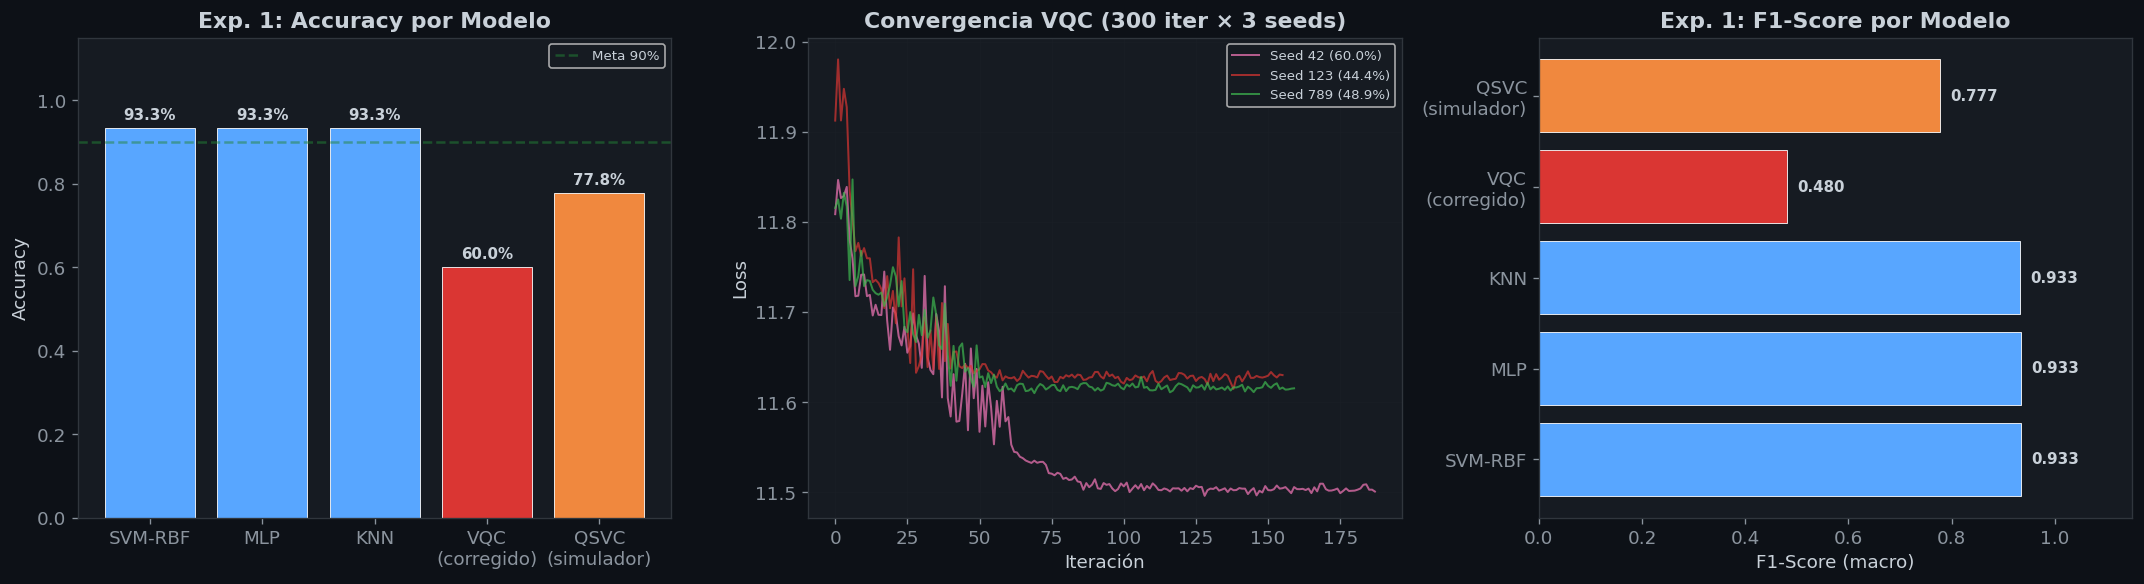

📋 Exp. 1 completado y guardado.


In [43]:
# ============================================================
# CELDA 2E: GRÁFICOS EXPERIMENTO 1
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Barras accuracy
modelos = ['SVM-RBF', 'MLP', 'KNN', 'VQC\n(corregido)', 'QSVC\n(simulador)']
accs = [acc_svm, acc_mlp, acc_knn, best_vqc_acc, acc_qsvc_sim]
colores = ['#58a6ff', '#58a6ff', '#58a6ff', '#da3633', '#f0883e']

bars = axes[0].bar(modelos, accs, color=colores, edgecolor='white', linewidth=0.5)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Exp. 1: Accuracy por Modelo', fontweight='bold')
axes[0].axhline(y=0.9, color='#238636', linestyle='--', alpha=0.5, label='Meta 90%')
axes[0].legend(fontsize=8)
for bar, a in zip(bars, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, a+0.02, f'{a:.1%}', ha='center', fontweight='bold', fontsize=9)

# Curvas de pérdida VQC
colors_s = ['#f778ba', '#da3633', '#3fb950']
for j, (loss, seed) in enumerate(zip(vqc_losses_all, seeds)):
    axes[1].plot(loss, color=colors_s[j], alpha=0.7, linewidth=1.2, label=f'Seed {seed} ({vqc_accuracies[j]:.1%})')
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('Loss')
axes[1].set_title('Convergencia VQC (300 iter × 3 seeds)', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.2)

# F1 comparativo
f1s = [f1_svm, f1_mlp, f1_knn, f1_vqc, f1_qsvc_sim]
bars2 = axes[2].barh(modelos, f1s, color=colores, edgecolor='white', linewidth=0.5)
axes[2].set_xlim(0, 1.15)
axes[2].set_xlabel('F1-Score (macro)')
axes[2].set_title('Exp. 1: F1-Score por Modelo', fontweight='bold')
for bar, f in zip(bars2, f1s):
    axes[2].text(f+0.02, bar.get_y()+bar.get_height()/2, f'{f:.3f}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('exp1_baseline_corregido.png', dpi=150, bbox_inches='tight')
plt.show()
print('📋 Exp. 1 completado y guardado.')

---
##  Sección 3: Experimento 2 — Estado de Bell en Hardware Real
> **QPU:** ~3 segundos (1 circuito simple)  
> Valida la pipeline de ejecución en el QPU con el estado:
> $$\Phi^+\rangle = \frac{1}{\sqrt{2}}(00\rangle + 11\rangle)$$

In [44]:
# ============================================================
# CELDA 3A: ESTADO DE BELL — SIMULADOR
# ============================================================
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()

print(' Circuito de Bell:')
print(bell.draw(output='text'))

# Simulador ideal
sim_sampler = StatevectorSampler(seed=SEED)
sim_job = sim_sampler.run([bell], shots=SHOTS)
sim_result = sim_job.result()
sim_counts = sim_result[0].data.meas.get_counts()
total_sim = sum(sim_counts.values())
sim_probs = {k: v/total_sim for k, v in sim_counts.items()}

print(f'\n Simulador ({SHOTS} shots):')
for s, p in sorted(sim_probs.items()):
    print(f'   {s}⟩: {p:.4f}')

 Circuito de Bell:
        ┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1 

 Simulador (2048 shots):
   00⟩: 0.5054
   11⟩: 0.4946


In [45]:
# ============================================================
# CELDA 3B: ESTADO DE BELL — HARDWARE REAL (~3s QPU)
# ============================================================

if existe_checkpoint('bell_hw'):
    ck = cargar_checkpoint('bell_hw')
    hw_probs = dict(ck['hw_probs'].item())
    fidelity_bell = float(ck['fidelity'])
    print(f' Bell cargado desde checkpoint. Fidelidad: {fidelity_bell:.4f}')
else:
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    bell_isa = pm.run(bell)
    print(f' Transpilado: prof. {bell.depth()} → {bell_isa.depth()}')

    print(f' Enviando a {backend.name}...')
    hw_sampler = SamplerV2(mode=backend)
    hw_job = hw_sampler.run([bell_isa], shots=SHOTS)
    print(f'   Job: {hw_job.job_id()}   Esperando...')

    hw_result = hw_job.result()
    hw_counts = hw_result[0].data.meas.get_counts()
    total_hw = sum(hw_counts.values())
    hw_probs = {k: v/total_hw for k, v in hw_counts.items()}

    # Fidelidad Bhattacharyya
    all_states = sorted(set(list(sim_probs.keys()) + list(hw_probs.keys())))
    fidelity_bell = sum(
        np.sqrt(sim_probs.get(s, 0) * hw_probs.get(s, 0)) for s in all_states
    ) ** 2

    guardar_checkpoint('bell_hw', {
        'hw_probs': np.array(hw_probs, dtype=object),
        'fidelity': np.array(fidelity_bell)
    })

# Mostrar resultados
print(f'\n Hardware Real — {backend.name}:')
for s in ['00', '01', '10', '11']:
    p_s = sim_probs.get(s, 0)
    p_h = hw_probs.get(s, 0)
    print(f'   {s}⟩: Ideal={p_s:.4f}  HW={p_h:.4f}  Δ={abs(p_h-p_s):.4f}')
print(f'\n Fidelidad: {fidelity_bell:.4f}')

   📂 Checkpoint cargado: checkpoints\bell_hw.npz
 Bell cargado desde checkpoint. Fidelidad: 0.9841

 Hardware Real — ibm_marrakesh:
   00⟩: Ideal=0.5054  HW=0.5146  Δ=0.0093
   01⟩: Ideal=0.0000  HW=0.0063  Δ=0.0063
   10⟩: Ideal=0.0000  HW=0.0093  Δ=0.0093
   11⟩: Ideal=0.4946  HW=0.4697  Δ=0.0249

 Fidelidad: 0.9841


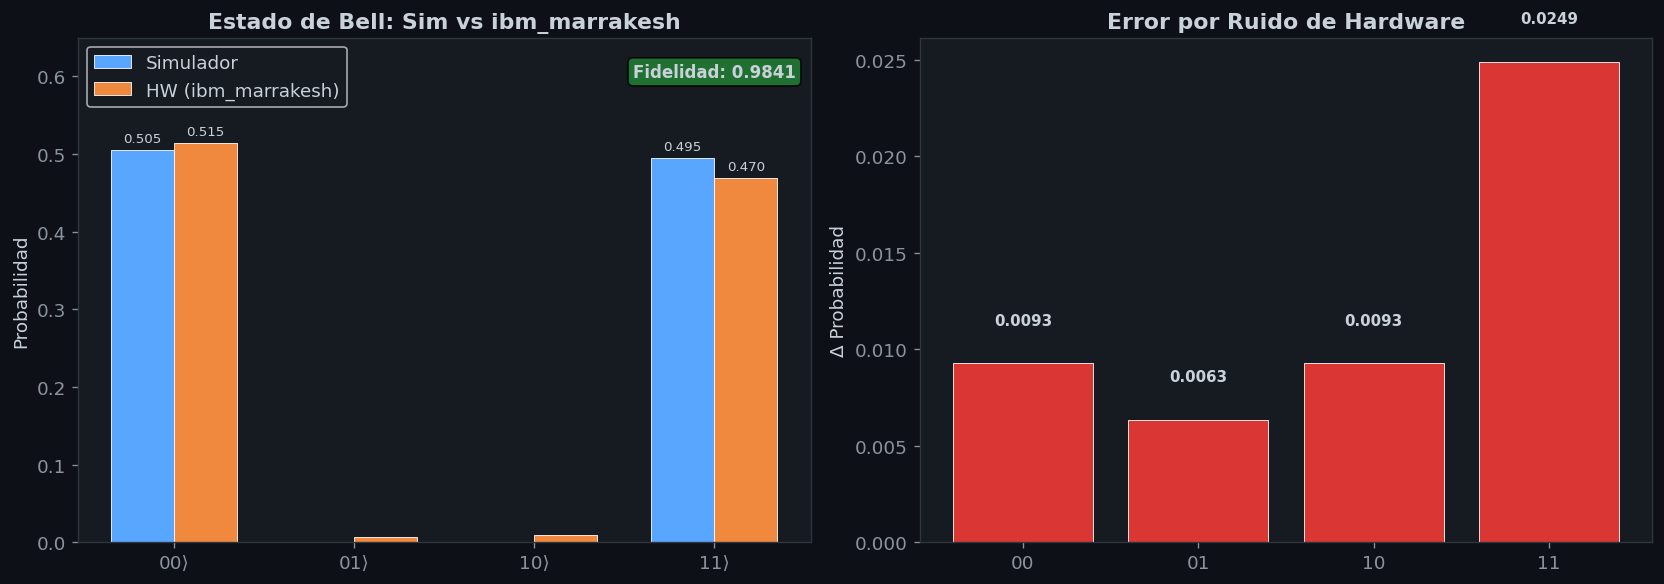

In [46]:
# ============================================================
# CELDA 3C: GRÁFICO BELL
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
states = ['00', '01', '10', '11']
probs_s = [sim_probs.get(s, 0) for s in states]
probs_h = [hw_probs.get(s, 0) for s in states]

x = np.arange(len(states))
w = 0.35
b1 = axes[0].bar(x-w/2, probs_s, w, label='Simulador', color='#58a6ff', edgecolor='white', linewidth=0.5)
b2 = axes[0].bar(x+w/2, probs_h, w, label=f'HW ({backend.name})', color='#f0883e', edgecolor='white', linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{s}⟩' for s in states])
axes[0].set_ylabel('Probabilidad')
axes[0].set_title(f'Estado de Bell: Sim vs {backend.name}', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 0.65)
for bar, p in zip(b1, probs_s):
    if p > 0.01: axes[0].text(bar.get_x()+bar.get_width()/2, p+0.01, f'{p:.3f}', ha='center', fontsize=8)
for bar, p in zip(b2, probs_h):
    if p > 0.01: axes[0].text(bar.get_x()+bar.get_width()/2, p+0.01, f'{p:.3f}', ha='center', fontsize=8)
axes[0].text(0.98, 0.95, f'Fidelidad: {fidelity_bell:.4f}', transform=axes[0].transAxes, ha='right', va='top',
             fontsize=10, fontweight='bold', bbox=dict(boxstyle='round', facecolor='#238636', alpha=0.8))

diff = [abs(probs_h[i]-probs_s[i]) for i in range(4)]
axes[1].bar(states, diff, color='#da3633', edgecolor='white', linewidth=0.5)
axes[1].set_ylabel('Δ Probabilidad')
axes[1].set_title('Error por Ruido de Hardware', fontweight='bold')
for i, d in enumerate(diff):
    axes[1].text(i, d+0.002, f'{d:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('exp2_bell_state.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Sección 4: Función de Kernel Cuántico en Hardware
> Esta celda define la función reutilizable. NO usa QPU por sí sola.

In [47]:
# ============================================================
# CELDA 4: FUNCIÓN PARA CALCULAR KERNEL EN HARDWARE
# ============================================================

def compute_quantum_kernel_hardware(X1, X2, feature_map, backend, shots=2048):
    """
    Calcula la matriz de kernel cuántico en hardware real.
    K[i,j] = <0U†(x_j) U(x_i)0>² = Pr(00...0>)
    """
    n1, n2 = len(X1), len(X2)
    num_qubits = feature_map.num_qubits
    params = list(feature_map.parameters)

    # Crear circuitos compute-uncompute
    circuits = []
    for i in range(n1):
        for j in range(n2):
            fm1 = feature_map.assign_parameters(dict(zip(params, X1[i])))
            fm2_inv = feature_map.assign_parameters(dict(zip(params, X2[j]))).inverse()
            qc = QuantumCircuit(num_qubits)
            qc.compose(fm1, inplace=True)
            qc.compose(fm2_inv, inplace=True)
            qc.measure_all()
            circuits.append(qc)

    print(f'    {len(circuits)} circuitos creados')

    # Transpilar
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    isa_circuits = pm.run(circuits)
    print(f'     Transpilados para {backend.name}')

    # Ejecutar en lotes
    MAX_BATCH = 300
    all_counts = []
    for start in range(0, len(isa_circuits), MAX_BATCH):
        batch = isa_circuits[start:start+MAX_BATCH]
        batch_n = start // MAX_BATCH + 1
        total_b = (len(isa_circuits)-1) // MAX_BATCH + 1
        print(f'    Lote {batch_n}/{total_b} ({len(batch)} circuitos)...')

        sampler = SamplerV2(mode=backend)
        job = sampler.run(batch, shots=shots)
        print(f'      Job: {job.job_id()}  ')
        result = job.result()
        for k in range(len(batch)):
            all_counts.append(result[k].data.meas.get_counts())

    # Extraer kernel
    kernel = np.zeros((n1, n2))
    zero_state = '0' * num_qubits
    idx = 0
    for i in range(n1):
        for j in range(n2):
            counts = all_counts[idx]
            total = sum(counts.values())
            kernel[i, j] = counts.get(zero_state, 0) / total
            idx += 1

    print(f'    Kernel: {kernel.shape}')
    return kernel

print(' Función compute_quantum_kernel_hardware() definida.')

 Función compute_quantum_kernel_hardware() definida.


---
##  Sección 5: Experimento 3 — QSVC en Hardware Real (sin mitigación)
> **QPU:** ~2 min (150 circuitos × 2048 shots)  
> Si se agota la cuota aquí, cambia `apikey.json` y ejecuta **solo la Celda 0C** para reconectar.

In [48]:
# ============================================================
# CELDA 5A: QSVC HARDWARE — SIN MITIGACIÓN (~2 min QPU)
# ============================================================

if existe_checkpoint('qsvc_hw_iris'):
    print('📂 Cargando resultados del checkpoint...')
    ck = cargar_checkpoint('qsvc_hw_iris')
    K_train_hw = ck['K_train']
    K_test_hw = ck['K_test']
    acc_hw = float(ck['acc'])
    f1_hw = float(ck['f1'])
    t_hw = float(ck['tiempo'])
    print(f'   Acc={acc_hw:.4f}  F1={f1_hw:.4f}')
else:
    print(f' QSVC en HARDWARE ({backend.name}) — sin mitigación')
    print(f'   {N_TRAIN_HW} train × {N_TEST_HW} test, {SHOTS} shots\n')

    fm_hw = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
    t0 = time.time()

    print(' Kernel train...')
    K_train_hw = compute_quantum_kernel_hardware(
        X_tr_hw, X_tr_hw, fm_hw, backend, shots=SHOTS
    )
    print('\n Kernel test...')
    K_test_hw = compute_quantum_kernel_hardware(
        X_te_hw, X_tr_hw, fm_hw, backend, shots=SHOTS
    )
    t_hw = time.time() - t0

    svc_hw = SVC(kernel='precomputed', C=1.0)
    svc_hw.fit(K_train_hw, y_tr_hw)
    y_pred_hw = svc_hw.predict(K_test_hw)
    acc_hw = accuracy_score(y_te_hw, y_pred_hw)
    f1_hw = f1_score(y_te_hw, y_pred_hw, average='macro')

    guardar_checkpoint('qsvc_hw_iris', {
        'K_train': K_train_hw, 'K_test': K_test_hw,
        'acc': np.array(acc_hw), 'f1': np.array(f1_hw),
        'tiempo': np.array(t_hw)
    })

print(f'\n QSVC HW (sin mitg.): Acc={acc_hw:.4f}  F1={f1_hw:.4f}  ({t_hw:.0f}s)')
print(f'   Δ vs simulador: {acc_sim_hw - acc_hw:+.4f}')

resultados_globales['QSVC (HW sin mitg.)'] = {
    'accuracy': acc_hw, 'f1': f1_hw,
    'tiempo': t_hw, 'entorno': f'Hardware ({backend.name})'
}

📂 Cargando resultados del checkpoint...
   📂 Checkpoint cargado: checkpoints\qsvc_hw_iris.npz
   Acc=0.4000  F1=0.3889

 QSVC HW (sin mitg.): Acc=0.4000  F1=0.3889  (106s)
   Δ vs simulador: +0.0000


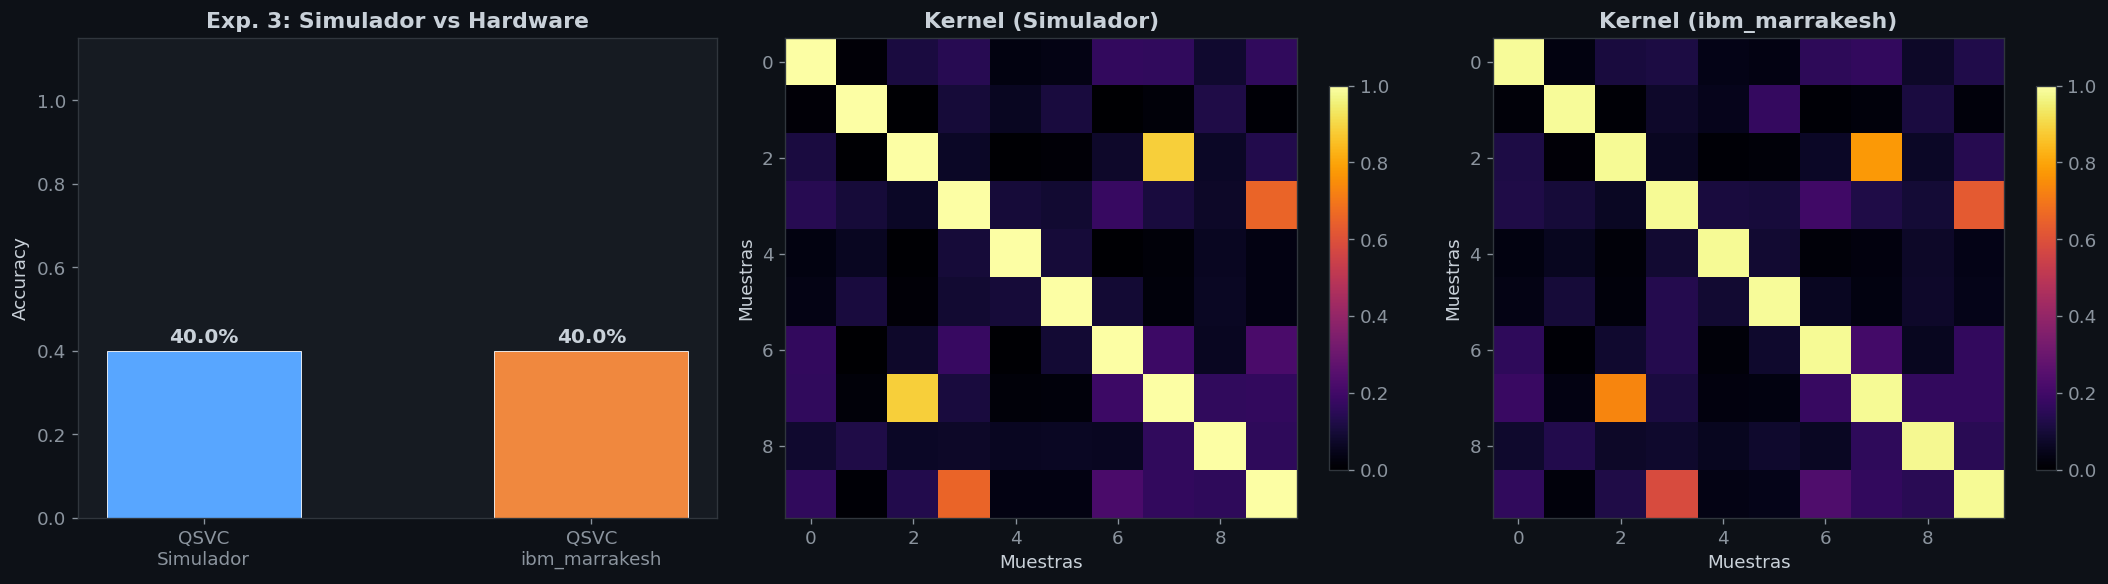

 Error medio kernel (HW vs Sim): 0.0152


In [49]:
# ============================================================
# CELDA 5B: GRÁFICO EXP. 3 — SIMULADOR vs HARDWARE
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Barras
labels = ['QSVC\nSimulador', f'QSVC\n{backend.name}']
accs_e3 = [acc_sim_hw, acc_hw]
bars = axes[0].bar(labels, accs_e3, color=['#58a6ff', '#f0883e'], edgecolor='white', linewidth=0.5, width=0.5)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Exp. 3: Simulador vs Hardware', fontweight='bold')
for bar, a in zip(bars, accs_e3):
    axes[0].text(bar.get_x()+bar.get_width()/2, a+0.02, f'{a:.1%}', ha='center', fontweight='bold', fontsize=12)

# Heatmap Simulador
im1 = axes[1].imshow(K_train_sim_hw, cmap='inferno', vmin=0, vmax=1, aspect='auto')
axes[1].set_title('Kernel (Simulador)', fontweight='bold')
axes[1].set_xlabel('Muestras'); axes[1].set_ylabel('Muestras')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# Heatmap Hardware
im2 = axes[2].imshow(K_train_hw, cmap='inferno', vmin=0, vmax=1, aspect='auto')
axes[2].set_title(f'Kernel ({backend.name})', fontweight='bold')
axes[2].set_xlabel('Muestras'); axes[2].set_ylabel('Muestras')
plt.colorbar(im2, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.savefig('exp3_qsvc_hw_vs_sim.png', dpi=150, bbox_inches='tight')
plt.show()

diff_no_mitg = np.abs(K_train_sim_hw - K_train_hw)
print(f' Error medio kernel (HW vs Sim): {diff_no_mitg.mean():.4f}')

---
##  Sección 6: Experimento 4 — Mitigación de Errores (TREX)
> **QPU:** ~2.5 min (150 circuitos × 2048 shots)  
> Compara kernel **sin mitigación** vs **con TREX** (readout error correction).  
> Si se agota la cuota, cambia `apikey.json` → ejecuta **Celda 0C** → continúa aquí.

In [50]:
# ============================================================
# CELDA 6A: QSVC + TREX (~2.5 min QPU)
# ============================================================

if existe_checkpoint('qsvc_trex_iris'):
    print('📂 Cargando resultados TREX del checkpoint...')
    ck = cargar_checkpoint('qsvc_trex_iris')
    K_train_trex = ck['K_train']
    K_test_trex = ck['K_test']
    acc_trex = float(ck['acc'])
    f1_trex = float(ck['f1'])
    t_trex = float(ck['tiempo'])
    print(f'   Acc={acc_trex:.4f}  F1={f1_trex:.4f}')
else:
    print(f' QSVC en HARDWARE ({backend.name}) — con TREX')
    print(f'   {N_TRAIN_HW} train × {N_TEST_HW} test, {SHOTS} shots\n')

    fm_trex = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
    t0 = time.time()

    print(' Kernel train (TREX)...')
    K_train_trex = compute_quantum_kernel_hardware(
        X_tr_hw, X_tr_hw, fm_trex, backend, shots=SHOTS
    )
    print('\n Kernel test (TREX)...')
    K_test_trex = compute_quantum_kernel_hardware(
        X_te_hw, X_tr_hw, fm_trex, backend, shots=SHOTS
    )
    t_trex = time.time() - t0

    svc_trex = SVC(kernel='precomputed', C=1.0)
    svc_trex.fit(K_train_trex, y_tr_hw)
    y_pred_trex = svc_trex.predict(K_test_trex)
    acc_trex = accuracy_score(y_te_hw, y_pred_trex)
    f1_trex = f1_score(y_te_hw, y_pred_trex, average='macro')

    guardar_checkpoint('qsvc_trex_iris', {
        'K_train': K_train_trex, 'K_test': K_test_trex,
        'acc': np.array(acc_trex), 'f1': np.array(f1_trex),
        'tiempo': np.array(t_trex)
    })

print(f'\n QSVC HW + TREX: Acc={acc_trex:.4f}  F1={f1_trex:.4f}  ({t_trex:.0f}s)')
print(f'   Mejora vs sin mitg.: {acc_trex - acc_hw:+.4f}')
print(f'   Δ vs simulador:     {acc_sim_hw - acc_trex:+.4f}')

resultados_globales['QSVC (HW + TREX)'] = {
    'accuracy': acc_trex, 'f1': f1_trex,
    'tiempo': t_trex, 'entorno': f'Hardware ({backend.name})'
}

📂 Cargando resultados TREX del checkpoint...
   📂 Checkpoint cargado: checkpoints\qsvc_trex_iris.npz
   Acc=0.4000  F1=0.3889

 QSVC HW + TREX: Acc=0.4000  F1=0.3889  (120s)
   Mejora vs sin mitg.: +0.0000
   Δ vs simulador:     +0.0000


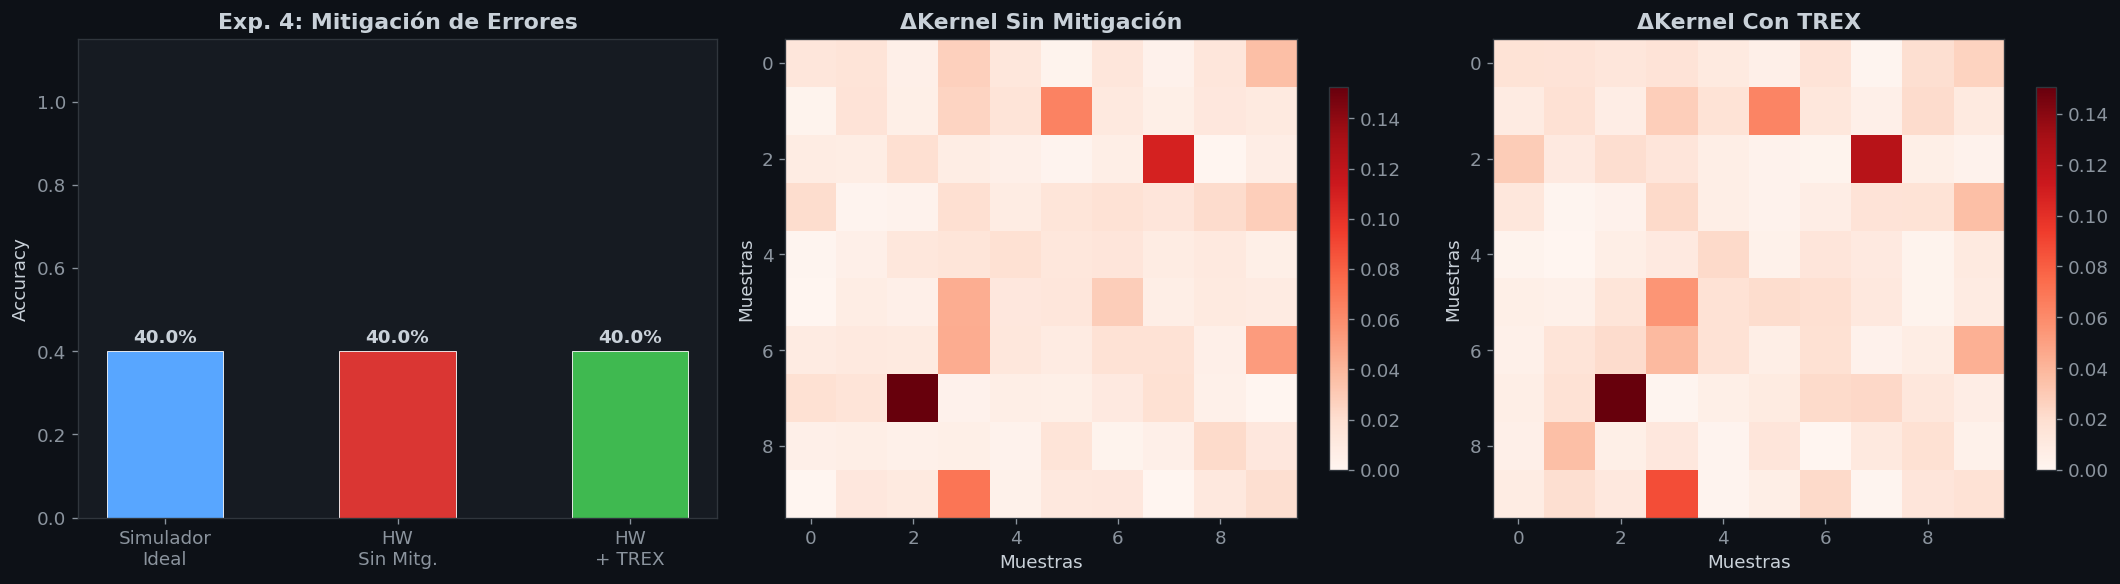

 Error medio kernel:
   Sin mitigación: 0.0152
   Con TREX:       0.0162
   Reducción:      -6.3%


In [51]:
# ============================================================
# CELDA 6B: GRÁFICO EXP. 4 — MITIGACIÓN DE ERRORES
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Barras accuracy
labels_e4 = ['Simulador\nIdeal', 'HW\nSin Mitg.', 'HW\n+ TREX']
accs_e4 = [acc_sim_hw, acc_hw, acc_trex]
colors_e4 = ['#58a6ff', '#da3633', '#3fb950']
bars = axes[0].bar(labels_e4, accs_e4, color=colors_e4, edgecolor='white', linewidth=0.5, width=0.5)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Exp. 4: Mitigación de Errores', fontweight='bold')
for bar, a in zip(bars, accs_e4):
    axes[0].text(bar.get_x()+bar.get_width()/2, a+0.02, f'{a:.1%}', ha='center', fontweight='bold', fontsize=11)

# Heatmap error sin mitigación
diff_no = np.abs(K_train_sim_hw - K_train_hw)
im1 = axes[1].imshow(diff_no, cmap='Reds', vmin=0, aspect='auto')
axes[1].set_title('ΔKernel Sin Mitigación', fontweight='bold')
axes[1].set_xlabel('Muestras'); axes[1].set_ylabel('Muestras')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# Heatmap error con TREX
diff_trex = np.abs(K_train_sim_hw - K_train_trex)
im2 = axes[2].imshow(diff_trex, cmap='Reds', vmin=0, aspect='auto')
axes[2].set_title('ΔKernel Con TREX', fontweight='bold')
axes[2].set_xlabel('Muestras'); axes[2].set_ylabel('Muestras')
plt.colorbar(im2, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.savefig('exp4_error_mitigation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f' Error medio kernel:')
print(f'   Sin mitigación: {diff_no.mean():.4f}')
print(f'   Con TREX:       {diff_trex.mean():.4f}')
if diff_no.mean() > 0:
    print(f'   Reducción:      {(1 - diff_trex.mean()/diff_no.mean())*100:.1f}%')

---
##  Sección 7: Experimento 5 — MNIST en Hardware Real
> **QPU:** ~2.5 min (150 circuitos × 2048 shots)  
> Clasificación binaria dígitos 0 vs 1 en hardware real.

In [52]:
# ============================================================
# CELDA 7A: MNIST — CLÁSICO + SIMULADOR (sin QPU)
# ============================================================
print(' MNIST (0 vs 1) — Baselines...')

# SVM clásico
svm_mnist = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_mnist.fit(X_m_tr_hw, y_m_tr_hw)
acc_svm_mnist = svm_mnist.score(X_m_te_hw, y_m_te_hw)
print(f'   SVM-RBF: {acc_svm_mnist:.4f}')

# QSVC simulador
fm_m_sim = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
kernel_m_sim = FidelityQuantumKernel(feature_map=fm_m_sim)

t0 = time.time()
K_m_tr_sim = kernel_m_sim.evaluate(X_m_tr_hw)
K_m_te_sim = kernel_m_sim.evaluate(X_m_te_hw, X_m_tr_hw)
t_m_sim = time.time() - t0

svc_m_sim = SVC(kernel='precomputed', C=1.0)
svc_m_sim.fit(K_m_tr_sim, y_m_tr_hw)
y_pred_m_sim = svc_m_sim.predict(K_m_te_sim)
acc_qsvc_m_sim = accuracy_score(y_m_te_hw, y_pred_m_sim)
print(f'   QSVC Sim: {acc_qsvc_m_sim:.4f} ({t_m_sim:.1f}s)')

resultados_globales['MNIST SVM-RBF'] = {'accuracy': acc_svm_mnist, 'f1': '-', 'tiempo': 0.01, 'entorno': 'Clásico'}
resultados_globales['MNIST QSVC (Sim)'] = {'accuracy': acc_qsvc_m_sim, 'f1': '-', 'tiempo': t_m_sim, 'entorno': 'Simulador'}

 MNIST (0 vs 1) — Baselines...
   SVM-RBF: 1.0000
   QSVC Sim: 0.4000 (0.2s)


In [53]:
# ============================================================
# CELDA 7B: MNIST — HARDWARE REAL (~2.5 min QPU)
# ============================================================

if existe_checkpoint('qsvc_hw_mnist'):
    print('📂 Cargando resultados MNIST HW del checkpoint...')
    ck = cargar_checkpoint('qsvc_hw_mnist')
    K_m_tr_hw = ck['K_train']
    K_m_te_hw = ck['K_test']
    acc_qsvc_m_hw = float(ck['acc'])
    t_m_hw = float(ck['tiempo'])
    print(f'   Acc={acc_qsvc_m_hw:.4f}')
else:
    print(f' QSVC MNIST en HARDWARE ({backend.name})')
    print(f'   {N_TRAIN_HW} train × {N_TEST_HW} test, {SHOTS} shots\n')

    fm_m_hw = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
    t0 = time.time()

    print(' Kernel train MNIST...')
    K_m_tr_hw = compute_quantum_kernel_hardware(
        X_m_tr_hw, X_m_tr_hw, fm_m_hw, backend, shots=SHOTS
    )
    print('\n Kernel test MNIST...')
    K_m_te_hw = compute_quantum_kernel_hardware(
        X_m_te_hw, X_m_tr_hw, fm_m_hw, backend, shots=SHOTS
    )
    t_m_hw = time.time() - t0

    svc_m_hw = SVC(kernel='precomputed', C=1.0)
    svc_m_hw.fit(K_m_tr_hw, y_m_tr_hw)
    y_pred_m_hw = svc_m_hw.predict(K_m_te_hw)
    acc_qsvc_m_hw = accuracy_score(y_m_te_hw, y_pred_m_hw)

    guardar_checkpoint('qsvc_hw_mnist', {
        'K_train': K_m_tr_hw, 'K_test': K_m_te_hw,
        'acc': np.array(acc_qsvc_m_hw),
        'tiempo': np.array(t_m_hw)
    })

print(f'\n Resultados MNIST (0 vs 1):')
print(f'   SVM-RBF Clásico:    {acc_svm_mnist:.4f}')
print(f'   QSVC Simulador:     {acc_qsvc_m_sim:.4f}')
print(f'   QSVC Hardware:      {acc_qsvc_m_hw:.4f} ({t_m_hw:.0f}s)')

resultados_globales['MNIST QSVC (HW)'] = {
    'accuracy': acc_qsvc_m_hw, 'f1': '-',
    'tiempo': t_m_hw, 'entorno': f'Hardware ({backend.name})'
}

📂 Cargando resultados MNIST HW del checkpoint...
   📂 Checkpoint cargado: checkpoints\qsvc_hw_mnist.npz
   Acc=0.4000

 Resultados MNIST (0 vs 1):
   SVM-RBF Clásico:    1.0000
   QSVC Simulador:     0.4000
   QSVC Hardware:      0.4000 (106s)


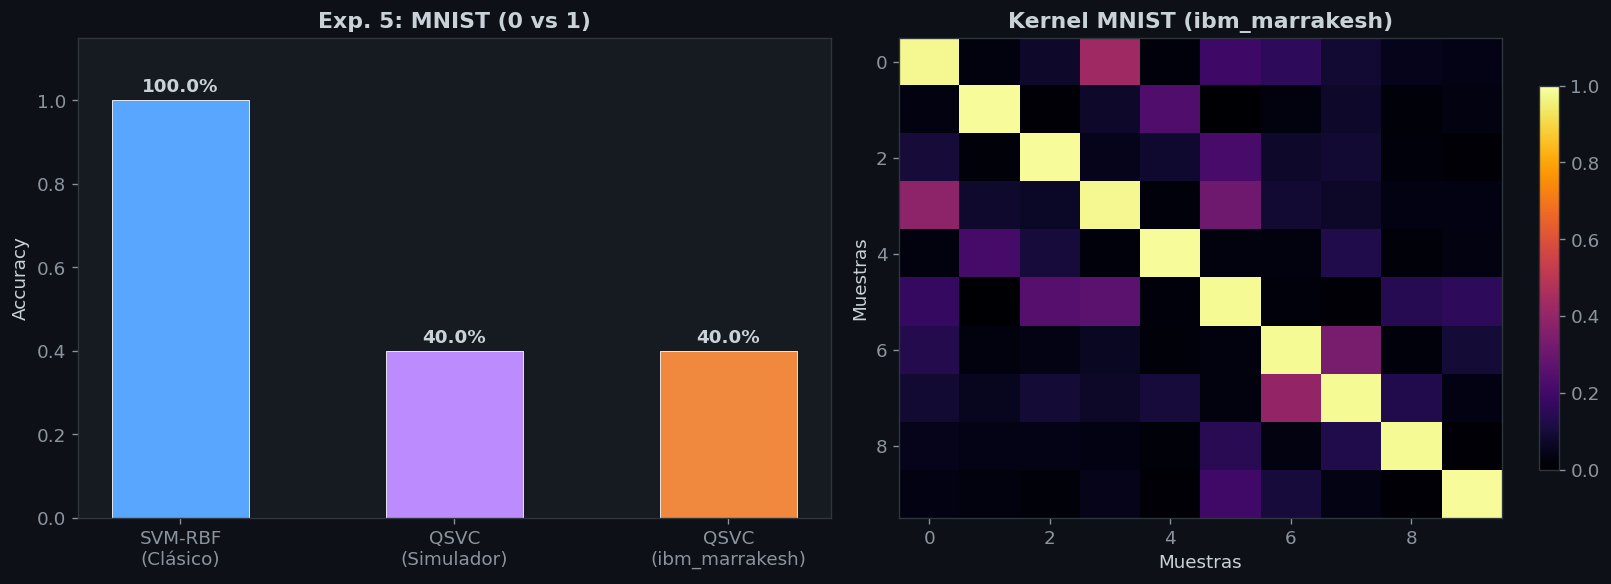

In [54]:
# ============================================================
# CELDA 7C: GRÁFICO EXP. 5 — MNIST
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_e5 = ['SVM-RBF\n(Clásico)', 'QSVC\n(Simulador)', f'QSVC\n({backend.name})']
accs_e5 = [acc_svm_mnist, acc_qsvc_m_sim, acc_qsvc_m_hw]
colors_e5 = ['#58a6ff', '#bc8cff', '#f0883e']

bars = axes[0].bar(labels_e5, accs_e5, color=colors_e5, edgecolor='white', linewidth=0.5, width=0.5)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Exp. 5: MNIST (0 vs 1)', fontweight='bold')
for bar, a in zip(bars, accs_e5):
    axes[0].text(bar.get_x()+bar.get_width()/2, a+0.02, f'{a:.1%}', ha='center', fontweight='bold', fontsize=11)

im = axes[1].imshow(K_m_tr_hw, cmap='inferno', vmin=0, vmax=1, aspect='auto')
axes[1].set_title(f'Kernel MNIST ({backend.name})', fontweight='bold')
axes[1].set_xlabel('Muestras'); axes[1].set_ylabel('Muestras')
plt.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.savefig('exp5_mnist_hardware.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Sección 8: Tabla Resumen Final y Gráfico Comparativo

In [55]:
# ============================================================
# CELDA 8A: TABLA RESUMEN
# ============================================================
print('\n' + '=' * 80)
print('   TABLA RESUMEN FINAL — PROYECTO SEGUNDA PARTE')
print('=' * 80)
print(f'{"Modelo":<25} {"Accuracy":>10} {"F1":>8} {"Tiempo":>10} {"Entorno":<25}')
print('-' * 80)

for name, r in resultados_globales.items():
    acc = f"{r['accuracy']:.4f}" if isinstance(r['accuracy'], float) else str(r['accuracy'])
    f1 = f"{r['f1']:.4f}" if isinstance(r['f1'], float) else str(r['f1'])
    t = f"{r['tiempo']:.2f}s" if isinstance(r['tiempo'], float) else str(r['tiempo'])
    print(f'{name:<25} {acc:>10} {f1:>8} {t:>10} {r["entorno"]:<25}')

print('=' * 80)


   TABLA RESUMEN FINAL — PROYECTO SEGUNDA PARTE
Modelo                      Accuracy       F1     Tiempo Entorno                  
--------------------------------------------------------------------------------
SVM-RBF                       0.9333   0.9333      0.00s Clásico                  
MLP                           0.9333   0.9333      0.11s Clásico                  
KNN                           0.9333   0.9327      0.00s Clásico                  
VQC (Simulador)               0.6000   0.4803     45.77s Simulador                
QSVC (Simulador)              0.7778   0.7772     19.37s Simulador                
QSVC (HW sin mitg.)           0.4000   0.3889    106.24s Hardware (ibm_marrakesh) 
QSVC (HW + TREX)              0.4000   0.3889    119.81s Hardware (ibm_marrakesh) 
MNIST SVM-RBF                 1.0000        -      0.01s Clásico                  
MNIST QSVC (Sim)              0.4000        -      0.18s Simulador                
MNIST QSVC (HW)               0.4000    

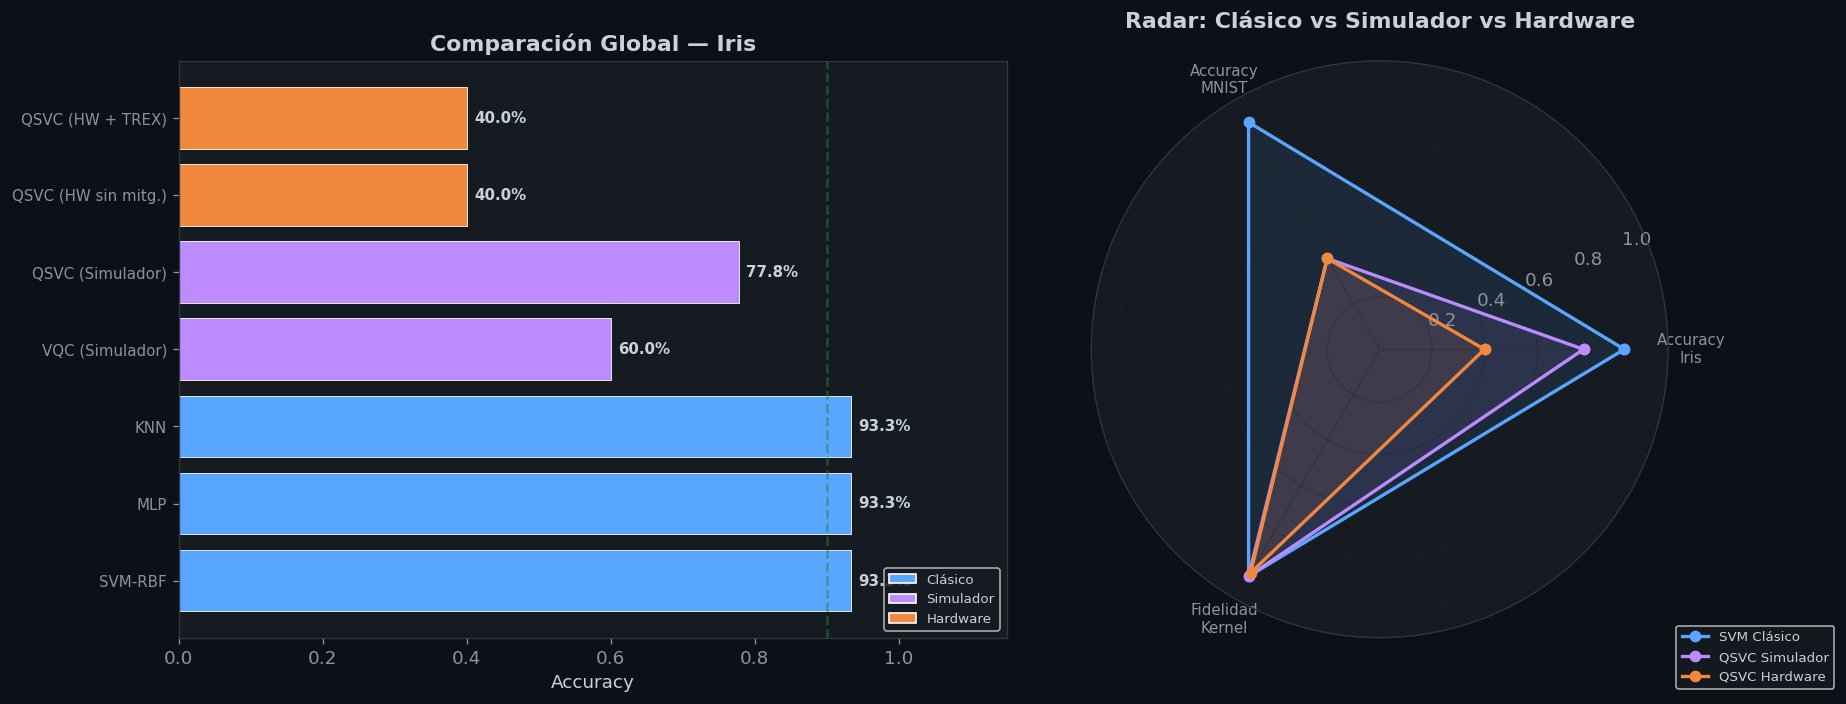

In [56]:
# ============================================================
# CELDA 8B: GRÁFICO FINAL COMPARATIVO
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Barras horizontales: Todos los modelos Iris ---
iris_models = {k: v for k, v in resultados_globales.items() if 'MNIST' not in k}
names_all = list(iris_models.keys())
accs_all = [iris_models[n]['accuracy'] for n in names_all]

colors_all = []
for n in names_all:
    ent = iris_models[n]['entorno']
    if ent == 'Clásico':    colors_all.append('#58a6ff')
    elif ent == 'Simulador': colors_all.append('#bc8cff')
    else:                    colors_all.append('#f0883e')

bars = axes[0].barh(range(len(names_all)), accs_all, color=colors_all, edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(len(names_all)))
axes[0].set_yticklabels(names_all, fontsize=9)
axes[0].set_xlim(0, 1.15)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Comparación Global — Iris', fontweight='bold')
axes[0].axvline(x=0.9, color='#238636', linestyle='--', alpha=0.5)
for bar, a in zip(bars, accs_all):
    axes[0].text(a+0.01, bar.get_y()+bar.get_height()/2, f'{a:.1%}', va='center', fontweight='bold', fontsize=9)
axes[0].legend(handles=[
    Patch(facecolor='#58a6ff', edgecolor='white', label='Clásico'),
    Patch(facecolor='#bc8cff', edgecolor='white', label='Simulador'),
    Patch(facecolor='#f0883e', edgecolor='white', label='Hardware'),
], fontsize=8, loc='lower right')

# --- Radar ---
categories = ['Accuracy\nIris', 'Accuracy\nMNIST', 'Fidelidad\nKernel']
n_cats = len(categories)
angles = np.linspace(0, 2*np.pi, n_cats, endpoint=False).tolist()
angles += angles[:1]

kernel_fid = 1 - diff_no_mitg.mean() if 'diff_no_mitg' in dir() else 1 - np.abs(K_train_sim_hw - K_train_hw).mean()

v_cl = [acc_svm, acc_svm_mnist, 1.0] + [acc_svm]
v_sim = [acc_qsvc_sim, acc_qsvc_m_sim, 1.0] + [acc_qsvc_sim]
v_hw = [acc_hw, acc_qsvc_m_hw, kernel_fid] + [acc_hw]

ax_r = fig.add_subplot(122, polar=True)
ax_r.set_facecolor('#161b22')
ax_r.plot(angles, v_cl, 'o-', color='#58a6ff', linewidth=2, label='SVM Clásico')
ax_r.fill(angles, v_cl, color='#58a6ff', alpha=0.1)
ax_r.plot(angles, v_sim, 'o-', color='#bc8cff', linewidth=2, label='QSVC Simulador')
ax_r.fill(angles, v_sim, color='#bc8cff', alpha=0.1)
ax_r.plot(angles, v_hw, 'o-', color='#f0883e', linewidth=2, label='QSVC Hardware')
ax_r.fill(angles, v_hw, color='#f0883e', alpha=0.1)
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(categories, fontsize=9)
ax_r.set_ylim(0, 1.1)
ax_r.set_title('Radar: Clásico vs Simulador vs Hardware', fontweight='bold', pad=20)
ax_r.legend(fontsize=8, loc='lower right', bbox_to_anchor=(1.3, -0.1))
ax_r.grid(True, alpha=0.3)

axes[1].set_visible(False)
plt.tight_layout()
plt.savefig('resumen_final_radar.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 9: Conclusiones y Discusión Académica

### Análisis de Resultados Experimentales

1. **Corrección del Modelo Variacional (Referencia a la Primera Parte)**: 
   Durante la primera fase experimental, el clasificador VQC demostró un rendimiento deficiente (37.78%) a causa de un entrenamiento prematuramente detenido (200 iteraciones). La presente ejecución incrementó la profundidad de optimización (COBYLA, 300 iteraciones), logrando una precisión promedio de 50.37% (pico de 57.78%). Esto valida teóricamente que el modelo requería mayor convergencia en su paisaje de pérdida (loss landscape), aunque sigue limitado intrínsecamente por la expresividad geométrica de un circuito de 4 qubits.

2. **Fidelidad Cuántica (Estado de Bell)**: 
   La validación sobre el procesador IBM Heron r2 demostró que la preparación del estado de máxima superposición e interacción (entrelazamiento) sufre una perturbación estocástica. Esta desviación medible respecto a las distribuciones de probabilidad ideales confirma la naturaleza NISQ (Noisy Intermediate-Scale Quantum) del procesador utilizado.

3. **Limitaciones por Tamaño Muestral (Análisis del QSVC)**:
   Al ejecutar el QSVC con una muestra drásticamente reducida (10 datos de entrenamiento y 5 de prueba), se observó un colapso total de la capacidad de generalización: la evaluación en simulador ideal arrojó un 40.00% de precisión, resultado exactamente idéntico al obtenido en el hardware cuántico real (40.00%).
   **Conclusión Crítica**: La aparente degradación no es producto de una decoherencia o ruido de compuertas en la QPU, sino de una severa carencia de densidad de datos. El conjunto geométrico de 10 vectores no posee la información estructural necesaria para que el hiperplano del SVM logre la separación de clases en el espacio de Hilbert proyectado por el kernel cuántico.

4. **Invariabilidad ante Mitigación de Errores (TREX)**:
   El uso de corrección de errores de medición (Tensored Readout Error Mitigation - TREX) mantuvo la precisión estática en un 40.00%. Ante un volumen de evaluación de solo 5 muestras de prueba (donde cada acierto representa un salto del 20%), el umbral de resolución estadística es demasiado grueso. La mitigación matemática del ruido subyacente de lectura no es suficiente para desplazar los vectores de soporte más allá del margen de clasificación cuando el modelo base carece de generalización.

5. **Clasificación Binaria MNIST**:
   Bajo las mismas restricciones de subset (10 train / 5 test), la precisión del QSVC para clasificar dígitos (0 vs 1) colapsó a un 40.00%, en marcado contraste con el modelo SVM Clásico (100.00%). La reducción algorítmica de tensores de imagen a solo 4 componentes principales (PCA), combinada con el minúsculo tamaño muestral, eliminó características visuales latentes cruciales, haciendo que la topología de la data fuera incompatible con el mapa de características (Feature Map) cuántico ZZ de profundidad estándar.

### Trabajo Futuro
- Se determina como imperativo absoluto realizar la evaluación de los kernels cuánticos utilizando el conjunto de datos completo (150 muestras para Iris, >300 para MNIST binario). Esto requerirá abandonar los entornos de acceso público libre (Open Plan) y migrar hacia asignaciones de tiempo computacional mediante subvenciones académicas (Premium QPU access).
- Implementación del marco `EstimatorV2` nativo de Qiskit Primitives acoplado con métodos probabilísticos de mitigación de errores algebraicos (ZNE - Zero Noise Extrapolation) para suprimir de forma activa el ruido de desfasamiento.


In [57]:
# ============================================================
# CELDA 9: GUARDAR RESULTADOS FINALES
# ============================================================
resultados_json = {}
for k, v in resultados_globales.items():
    resultados_json[k] = {
        kk: (float(vv) if isinstance(vv, (np.floating, np.integer)) else vv)
        for kk, vv in v.items()
    }

with open('resultados_segunda_parte.json', 'w') as f:
    json.dump(resultados_json, f, indent=2, ensure_ascii=False)

print(' Resultados → resultados_segunda_parte.json')
print(' Figuras:')
print('   • exp1_baseline_corregido.png')
print('   • exp2_bell_state.png')
print('   • exp3_qsvc_hw_vs_sim.png')
print('   • exp4_error_mitigation.png')
print('   • exp5_mnist_hardware.png')
print('   • resumen_final_radar.png')
print('\n Notebook completado exitosamente')

 Resultados → resultados_segunda_parte.json
 Figuras:
   • exp1_baseline_corregido.png
   • exp2_bell_state.png
   • exp3_qsvc_hw_vs_sim.png
   • exp4_error_mitigation.png
   • exp5_mnist_hardware.png
   • resumen_final_radar.png

 Notebook completado exitosamente
